About the dataset:
1. longitude: A measure of how far west a house is; a higher value is farther west
2. latitude: A measure of how far north a house is; a higher value is farther north
3. housingMedianAge: Median age of a house within a block; a lower number is a newer building
4. totalRooms: Total number of rooms within a block
5. totalBedrooms: Total number of bedrooms within a block
6. population: Total number of people residing within a block
7. households: Total number of households, a group of people residing within a home unit, for a block
8. medianIncome: Median income for households within a block of houses (measured in tens of thousands of US Dollars)
9. medianHouseValue: Median house value for households within a block (measured in US Dollars)
10. oceanProximity: Location of the house w.r.t ocean/sea

___
___

# EDA

In [128]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [129]:
df = pd.read_csv("housing.csv")
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [130]:
df.shape

(20640, 10)

There are 10 feature columns and 20640 individual data enteries(rows)

In [131]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


Among 10 columns 9 are float and one is string.
* Most columns have complete data; total_bedrooms has 20,433 non-null values, so 207 records are missing.

In [132]:
df.duplicated().sum()

np.int64(0)

No duplicated rows were found in the dataset.

In [133]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


**This is a descriptive summary of 20,640 California housing records** 

* Housing age: Median age is 29 years; the mean is 28.64. Ages range from 1 to 52 years.
* Rooms and bedrooms: The average block has about 2,636 rooms and 538 bedrooms. total_bedrooms has 207 missing values.
* Population and households: A block has an average population of about 1,425 and 500 households.
* Median income: The average is 3.87, or about $38,700 given the units; the median is 3.53 (about $35,300).
* Median house value: The average is about $206,856, while the median is $179,700. The higher mean suggests a right-skewed distribution, and the maximum value of $500,001 is capped in this dataset.

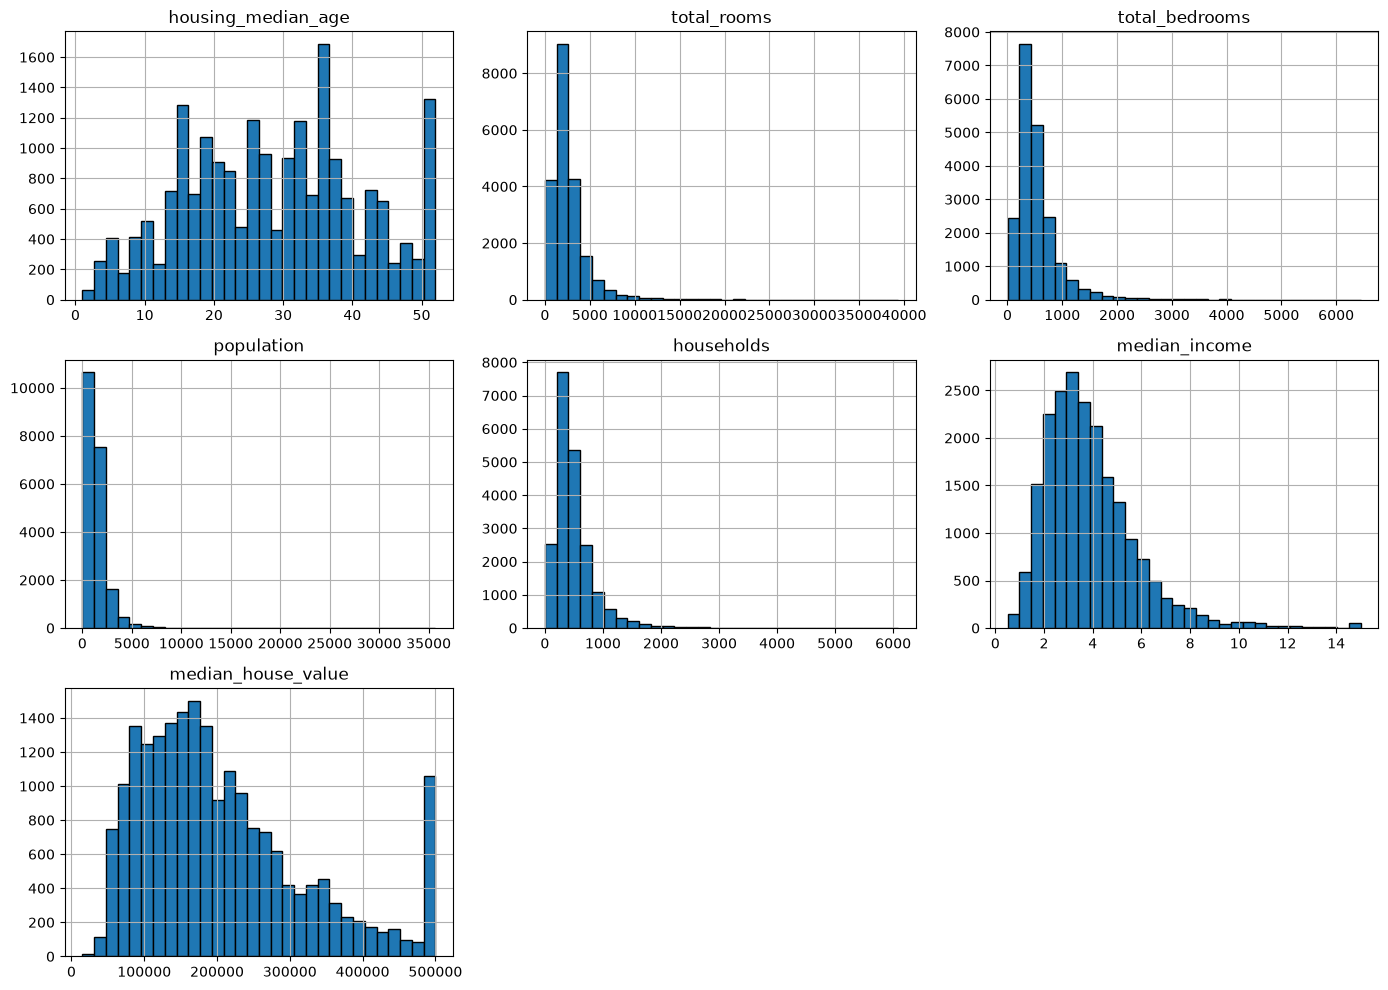

In [134]:
cols = [
    "housing_median_age", "total_rooms", "total_bedrooms",
    "population", "households", "median_income",
    "median_house_value"
]

df[cols].hist(bins=30, figsize=(14, 10), edgecolor="black")
plt.tight_layout()
plt.show()

The histograms show that most numeric features are **right-skewed**: many observations are concentrated at lower values, with a smaller number of very large values creating long tails.

- **housing_median_age:** Spread across roughly 1–52 years, with several peaks. There is a noticeable concentration near the upper end, around 50 years.
- **total_rooms:** Strongly right-skewed. Most districts have relatively few rooms, while a small number have very large totals.
- **total_bedrooms:** Also strongly right-skewed, with most values at the low end and a long tail of unusually high counts.
- **population:** Highly right-skewed; most districts have smaller populations, with a few extreme values.
- **households:** Right-skewed, similar to population and room counts.
- **median_income:** Concentrated mostly around 2–6, with a right tail extending to higher incomes.
- **median_house_value:** Most values fall around 100,000–300,000, with a right tail. The spike near 500,000 suggests the values may be capped at that level.

<Axes: xlabel='ocean_proximity'>

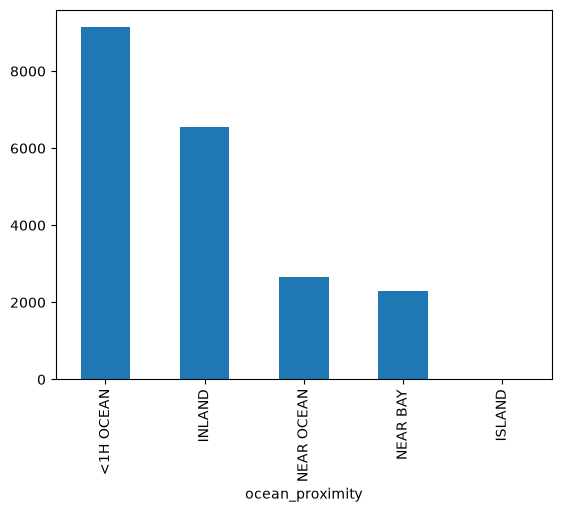

In [135]:
df.ocean_proximity.value_counts().plot(kind = "bar")

<Axes: >

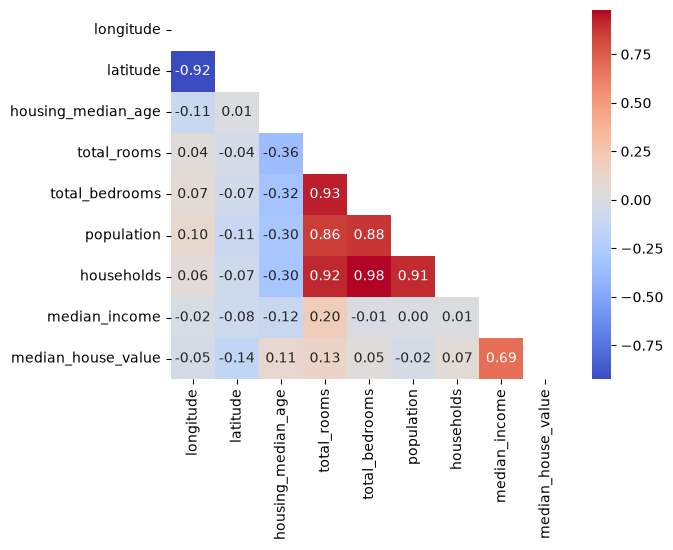

In [136]:
corr = df.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot = True , fmt = ".2f", cmap = "coolwarm", mask= mask)

Median income for households within a block of houses (measured in tens of thousands of US Dollars) has a positive correlation with Median house value for households within a block (measured in US Dollars)

* total_rooms and households are strongly related (0.92), as are total_bedrooms and households (0.98). These features share overlapping information, so we could compress a pair into one feature—for example, use rooms per household (total_rooms / households) to represent average household size in rooms.

___
___

# Data Preprocessing

In [137]:
df.fillna({"total_bedrooms": df.total_bedrooms.median()},inplace =True)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20640 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


In [138]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df[["median_income", "median_house_value"]] = scaler.fit_transform(
    df[["median_income", "median_house_value"]]
)

In [139]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,2.344766,2.129631,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,2.332238,1.314156,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,1.782699,1.258693,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,0.932968,1.165100,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,-0.012881,1.172900,NEAR BAY


In [140]:
df.corr(numeric_only= True)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
longitude,1.000000,-0.924664,-0.108197,0.044568,0.069120,0.099773,0.055310,-0.015176,-0.045967
latitude,-0.924664,1.000000,0.011173,-0.036100,-0.066484,-0.108785,-0.071035,-0.079809,-0.144160
housing_median_age,-0.108197,0.011173,1.000000,-0.361262,-0.319026,-0.296244,-0.302916,-0.119034,0.105623
total_rooms,0.044568,-0.036100,-0.361262,1.000000,0.927058,0.857126,0.918484,0.198050,0.134153
total_bedrooms,0.069120,-0.066484,-0.319026,0.927058,1.000000,0.873535,0.974366,-0.007617,0.049457
population,0.099773,-0.108785,-0.296244,0.857126,0.873535,1.000000,0.907222,0.004834,-0.024650
households,0.055310,-0.071035,-0.302916,0.918484,0.974366,0.907222,1.000000,0.013033,0.065843
median_income,-0.015176,-0.079809,-0.119034,0.198050,-0.007617,0.004834,0.013033,1.000000,0.688075
median_house_value,-0.045967,-0.144160,0.105623,0.134153,0.049457,-0.024650,0.065843,0.688075,1.000000


<Axes: >

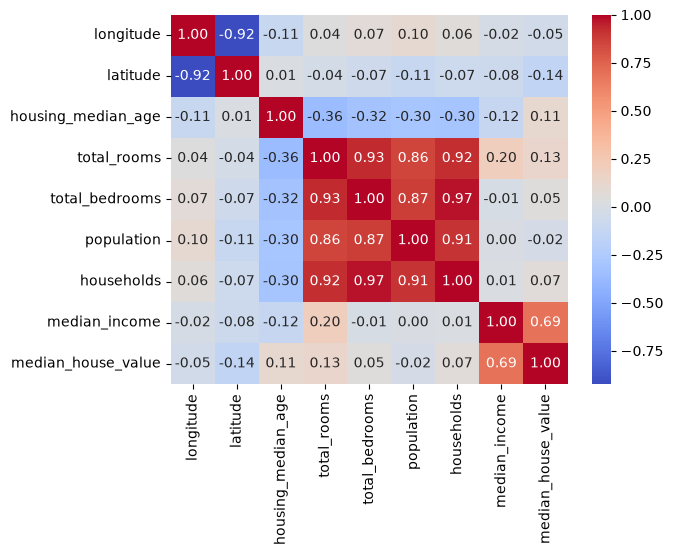

In [141]:
sns.heatmap(data = df.corr(numeric_only= True) ,annot = True, cmap = "coolwarm", fmt = ".2f")

In [142]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = X.select_dtypes(include=["int64", "float64"])

vif = pd.DataFrame()
vif["Feature"] = X_vif.columns
vif["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

print(vif)

                    Feature        VIF
0                 longitude   8.830423
1                  latitude   9.027200
2        housing_median_age   1.260357
3               total_rooms  16.123349
4            total_bedrooms  32.571417
5                population   6.684883
6                households  29.045576
7             median_income   1.866031
8         bedrooms_per_room   2.109978
9  population_per_household   1.062510


In [143]:
df.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='str')

In [144]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [145]:
X = df.drop(columns = "median_house_value")
y = df["median_house_value"]

In [146]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X.select_dtypes(include=["object", "category"]).columns

C:\Users\bobs9\AppData\Local\Temp\ipykernel_20920\3905257628.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=["object", "category"]).columns


In [147]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 0.4391151725342883
MSE : 0.3686287120249992
RMSE: 0.6071480149230493
R²  : 0.6254240620553634


In [150]:
residuals = y_test - y_pred

print(residuals.head())

20046   -0.055077
3024    -0.679638
15663    2.118950
20484   -0.428124
9814     0.131989
Name: median_house_value, dtype: float64


"The original dataset contained substantial multicollinearity among several count-based features, particularly total_rooms, total_bedrooms, and households. The engineered ratio features had relatively low VIF values, indicating that they did not introduce substantial multicollinearity. However, adding these engineered features did not improve the model's test-set performance."

Thus no feature were added to the original dataset.

___
___

# Assumptions of Linear Regression

Before trusting a Linear Regression model, we check some basic assumptions.

### 1. Linearity

The relationship between the **input variables (X)** and **target (y)** should be approximately linear.

**How to check:**
Use a residual vs predicted-value plot.

* Random scatter → good
* Curved pattern → possible problem

---

### 2. Independence

Each observation should be **independent** of the others.

For example, one house's data should not directly depend on another house's data.

**How to check:**

* Understand how the data was collected.
* For time-based data, check for autocorrelation.

---

### 3. Homoscedasticity

The residuals should have a **roughly constant spread** across different predicted values.

**How to check:**
Look at the residual vs predicted plot.

* Constant spread → good
* Funnel-shaped spread → possible heteroscedasticity

---

### 4. Normality of Residuals

The residuals should be **approximately normally distributed**, especially when doing statistical inference.

**How to check:**

* Histogram of residuals
* Q-Q plot

Since you noticed your residuals were **somewhat skewed**, this assumption may not be fully satisfied.

---

### 5. No Severe Multicollinearity

The independent variables should not be **too strongly related to each other**.

For example:

```text
area ↔ number of rooms
```

might be highly correlated.

**How to check:**
Use **VIF (Variance Inflation Factor)**.

---

### 6. No Highly Influential Outliers

Extreme observations should not have an **unreasonably large influence** on the model.

**How to check:**

* Residuals
* Standardized residuals
* Cook's distance

In your case, since you **didn't remove outliers**, mention this as a limitation rather than pretending the assumption was perfectly satisfied.

---

## Quick Summary

| Assumption            | How to check                     |
| --------------------- | -------------------------------- |
| **Linearity**         | Residual plot                    |
| **Independence**      | Data structure / autocorrelation |
| **Homoscedasticity**  | Residual plot                    |
| **Normality**         | Histogram / Q-Q plot             |
| **Multicollinearity** | VIF                              |
| **Outliers**          | Residuals / Cook's distance      |

**Easy way to remember:**

> Linear regression should have a **linear relationship, independent observations, constant error spread, approximately normal residuals, low multicollinearity, and no overly influential observations.**
